In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("kc_house_data.csv")

# -------------------------------
# 1. Inspect dataset
# -------------------------------
print("Initial shape:", df.shape)
print(df.info())
print(df.describe())

# -------------------------------
# 2. Handle missing values
# -------------------------------
# Drop rows with missing target (price)
df = df.dropna(subset=["price"])

# Numeric columns → fill with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Object/categorical columns → fill with mode
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------------
# 3. Remove duplicates
# -------------------------------
df = df.drop_duplicates()

# -------------------------------
# 4. Feature engineering
# -------------------------------
# Convert 'date' to datetime and extract features
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year_sold"] = df["date"].dt.year
df["month_sold"] = df["date"].dt.month
df = df.drop(columns=["date"])  # drop raw date if not needed

# Age of house at sale
df["house_age"] = df["year_sold"] - df["yr_built"]

# Renovation flag
df["renovated"] = np.where(df["yr_renovated"] > 0, 1, 0)

# Drop yr_built and yr_renovated if redundant
df = df.drop(columns=["yr_built", "yr_renovated"])

# -------------------------------
# 5. Encode categorical variables
# -------------------------------
encoder = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:  # only encode if still present
        df[col] = encoder.fit_transform(df[col])

# -------------------------------
# 6. Outlier removal
# -------------------------------
# Remove extreme values for key numeric features
for col in ["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"]:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# -------------------------------
# 7. Final check
# -------------------------------
print("Cleaned shape:", df.shape)
print(df.head())

# Save cleaned dataset
df.to_csv("house_data_cleaned.csv", index=False)


Initial shape: (21613, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 no

Shape: (19993, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19993 entries, 0 to 19992
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             19993 non-null  int64  
 1   price          19993 non-null  float64
 2   bedrooms       19993 non-null  int64  
 3   bathrooms      19993 non-null  float64
 4   sqft_living    19993 non-null  int64  
 5   sqft_lot       19993 non-null  int64  
 6   floors         19993 non-null  float64
 7   waterfront     19993 non-null  int64  
 8   view           19993 non-null  int64  
 9   condition      19993 non-null  int64  
 10  grade          19993 non-null  int64  
 11  sqft_above     19993 non-null  int64  
 12  sqft_basement  19993 non-null  int64  
 13  zipcode        19993 non-null  int64  
 14  lat            19993 non-null  float64
 15  long           19993 non-null  float64
 16  sqft_living15  19993 non-null  int64  
 17  sqft_lot15     19993 non-null  

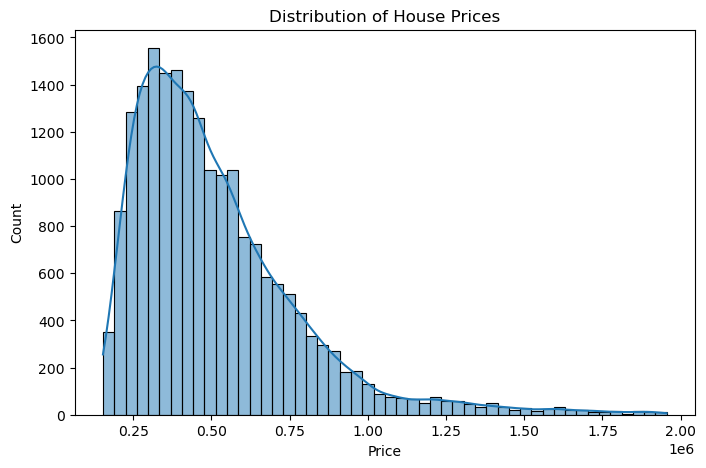

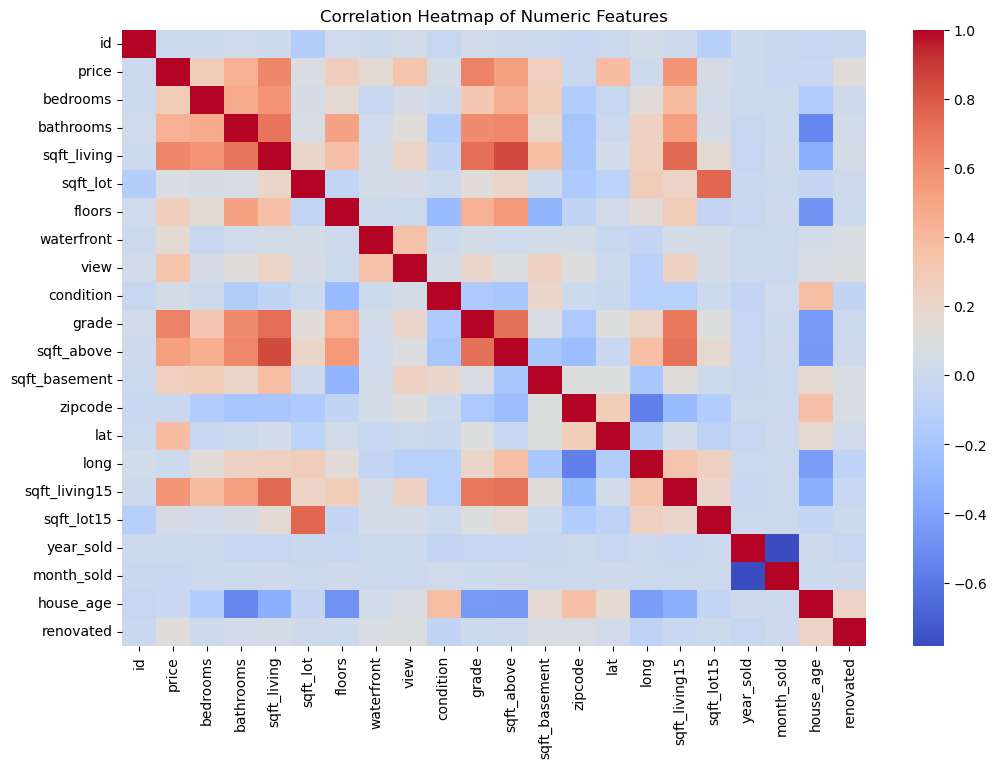

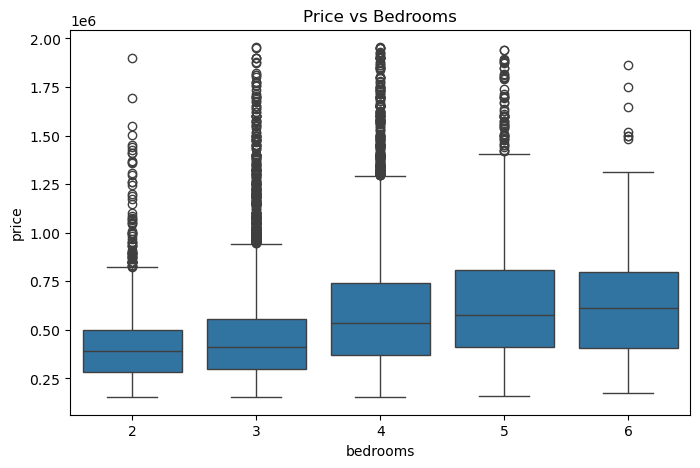

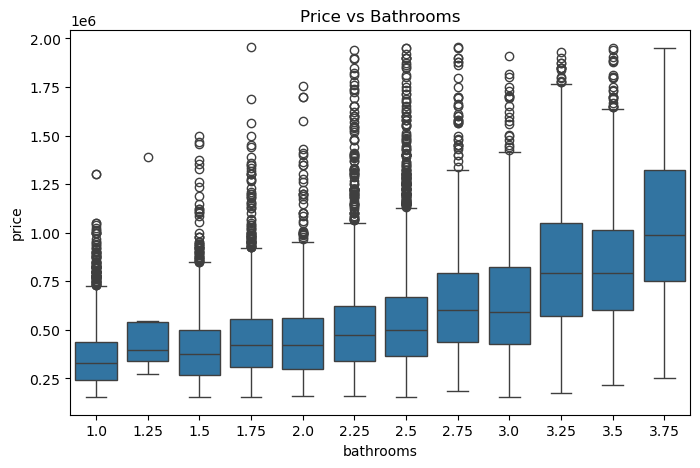

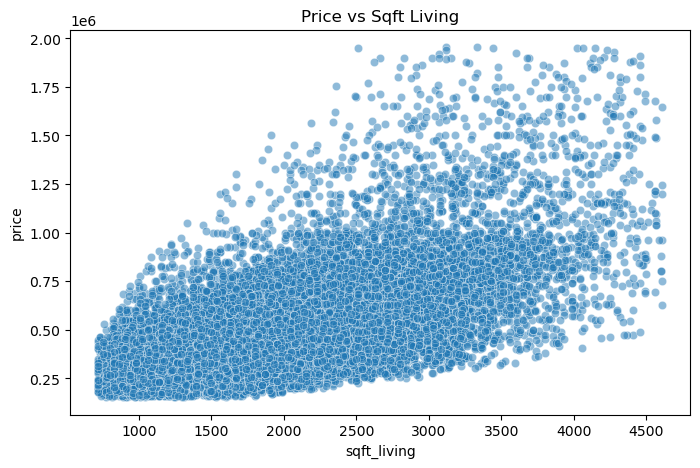

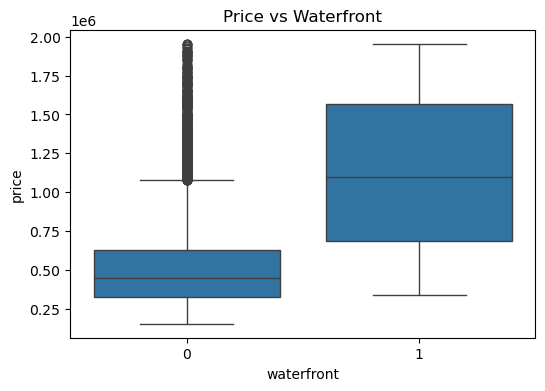

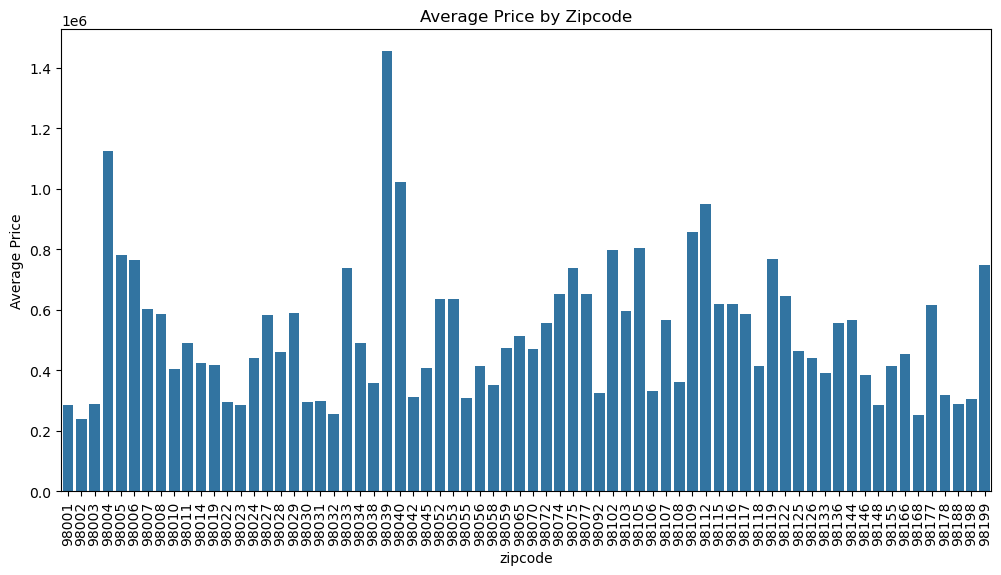

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Load dataset
df = pd.read_csv("house_data_cleaned.csv")

# Convert date column to datetime
#df["date"] = pd.to_datetime(df["date"], errors="coerce")



# -------------------------------
# 1. Basic overview
# -------------------------------
print("Shape:", df.shape)
print(df.info())
print(df.describe())

# -------------------------------
# 2. Target variable distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# -------------------------------
# 3. Correlation heatmap
# -------------------------------
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# -------------------------------
# 4. Feature relationships
# -------------------------------
# Price vs Bedrooms
plt.figure(figsize=(8,5))
sns.boxplot(x="bedrooms", y="price", data=df)
plt.title("Price vs Bedrooms")
plt.show()

# Price vs Bathrooms
plt.figure(figsize=(8,5))
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Price vs Bathrooms")
plt.show()

# Price vs Sqft Living
plt.figure(figsize=(8,5))
sns.scatterplot(x="sqft_living", y="price", data=df, alpha=0.5)
plt.title("Price vs Sqft Living")
plt.show()

# Price vs Waterfront
plt.figure(figsize=(6,4))
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("Price vs Waterfront")
plt.show()

# -------------------------------
# 5. Zipcode analysis
# -------------------------------
plt.figure(figsize=(12,6))
avg_price_zip = df.groupby("zipcode")["price"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_zip.index, y=avg_price_zip.values)
plt.xticks(rotation=90)
plt.title("Average Price by Zipcode")
plt.ylabel("Average Price")
plt.show()


In [9]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Load cleaned dataset
df = pd.read_csv("house_data_cleaned.csv")

X = df.drop(columns=["price"])
y = df["price"]

# -------------------------------
# 1. Correlation-based selection
# -------------------------------
corr_target = df.corr()["price"].sort_values(ascending=False)
corr_features = corr_target[corr_target.abs() > 0.05].index.tolist()  # keep features with correlation > 0.05
print("Correlation-selected features:", corr_features)

# -------------------------------
# 2. Random Forest importance
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_features = importances.head(15).index.tolist()  # top 15 features
print("Random Forest-selected features:", rf_features)

# -------------------------------
# 3. Recursive Feature Elimination (RFE)
# -------------------------------
lr = LinearRegression()
rfe = RFE(lr, n_features_to_select=10)
rfe.fit(X, y)
rfe_features = X.columns[rfe.support_].tolist()
print("RFE-selected features:", rfe_features)

# -------------------------------
# 4. Consolidated selection
# -------------------------------
# Take union of all selected features
final_features = list(set(corr_features) | set(rf_features) | set(rfe_features))
print("Final consolidated features:", final_features)

# -------------------------------
# 5. Reduced dataset
# -------------------------------
df_selected = df[final_features + ["price"]]
print("Shape after feature selection:", df_selected.shape)


Correlation-selected features: ['price', 'grade', 'sqft_living', 'sqft_living15', 'sqft_above', 'bathrooms', 'lat', 'view', 'bedrooms', 'floors', 'sqft_basement', 'waterfront', 'renovated', 'sqft_lot', 'sqft_lot15']
Random Forest-selected features: ['grade', 'lat', 'sqft_living', 'long', 'sqft_living15', 'house_age', 'zipcode', 'sqft_above', 'sqft_lot15', 'view', 'sqft_lot', 'waterfront', 'id', 'month_sold', 'bathrooms']
RFE-selected features: ['bedrooms', 'bathrooms', 'waterfront', 'view', 'condition', 'grade', 'lat', 'long', 'year_sold', 'renovated']
Final consolidated features: ['zipcode', 'waterfront', 'renovated', 'bathrooms', 'id', 'sqft_above', 'sqft_living15', 'sqft_lot', 'house_age', 'grade', 'long', 'month_sold', 'price', 'lat', 'sqft_living', 'view', 'floors', 'sqft_basement', 'condition', 'year_sold', 'bedrooms', 'sqft_lot15']
Shape after feature selection: (19993, 23)


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("house_data_cleaned.csv")

# Final consolidated features (from your selection step)
final_features = [
    'zipcode', 'waterfront', 'renovated', 'bathrooms', 'id', 'sqft_above',
    'sqft_living15', 'sqft_lot', 'house_age', 'grade', 'long', 'month_sold',
    'lat', 'sqft_living', 'view', 'floors', 'sqft_basement', 'condition',
    'year_sold', 'bedrooms', 'sqft_lot15'
]

# Define predictors (X) and target (y)
X = df[final_features]
y = df["price"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (15994, 21)
Test set shape: (3999, 21)


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load dataset
df = pd.read_csv("house_data_cleaned.csv")

# Final consolidated features
final_features = [
    'zipcode', 'waterfront', 'renovated', 'bathrooms', 'id', 'sqft_above',
    'sqft_living15', 'sqft_lot', 'house_age', 'grade', 'long', 'month_sold',
    'lat', 'sqft_living', 'view', 'floors', 'sqft_basement', 'condition',
    'year_sold', 'bedrooms', 'sqft_lot15'
]

X = df[final_features]
y = df["price"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 1. Linear Regression
# -------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))  # manual sqrt

# -------------------------------
# 2. Random Forest Regressor
# -------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))  


Linear Regression Results:
R² Score: 0.7013062159726973
RMSE: 146771.9640238757

Random Forest Results:
R² Score: 0.8750285570651452
RMSE: 94936.97848147465


In [18]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.6/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 2.4/101.7 MB 3.2 MB/s eta 0:00:32
   - -------------------------------------- 2.9/101.7 MB 3.2 MB/s eta 0:00:32
   - -------------------------------------- 3.7/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 4.5/101.7 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 5.0/101.7 MB 3.2 MB/s eta 0:00:31
   -- ------------------------------------- 5.8/101.7 MB 3.2 MB/s eta 0:00:30
   -- ------------------------------------- 6.6/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 7.1/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 7.6/101.7 MB 3.1 MB/s eta 0:00:31


In [22]:


from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv("house_data_cleaned.csv")

# Final consolidated features
final_features = [
    'zipcode', 'waterfront', 'renovated', 'bathrooms', 'id', 'sqft_above',
    'sqft_living15', 'sqft_lot', 'house_age', 'grade', 'long', 'month_sold',
    'lat', 'sqft_living', 'view', 'floors', 'sqft_basement', 'condition',
    'year_sold', 'bedrooms', 'sqft_lot15'
]

X = df[final_features]
y = df["price"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 1. Gradient Boosting Regressor
# -------------------------------
gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting Results:")
print("R² Score:", r2_score(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))

# -------------------------------
# 2. XGBoost Regressor
# -------------------------------
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("R² Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


Gradient Boosting Results:
R² Score: 0.8810256332380078
RMSE: 92631.07717508922

XGBoost Results:
R² Score: 0.9025818940016506
RMSE: 83820.4241730619


In [23]:


#new house data (must match your final_features)
new_data = pd.DataFrame({
    'zipcode': [98178],
    'waterfront': [0],
    'renovated': [0],
    'bathrooms': [2],
    'id': [1234567890],
    'sqft_above': [1200],
    'sqft_living15': [1500],
    'sqft_lot': [5000],
    'house_age': [20],
    'grade': [7],
    'long': [-122.2],
    'month_sold': [6],
    'lat': [47.5],
    'sqft_living': [1800],
    'view': [0],
    'floors': [1],
    'sqft_basement': [600],
    'condition': [3],
    'year_sold': [2026],
    'bedrooms': [3],
    'sqft_lot15': [4000]
})

# Predict price
predicted_price = xgb.predict(new_data)
print("Predicted House Price:", predicted_price[0])

# -------------------------------
# Show model performance metrics
# -------------------------------
# Evaluate on your test set
y_pred_test = xgb.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print("\nModel Performance on Test Data:")
print("R² Score:", r2)
print("RMSE:", rmse)


Predicted House Price: 309215.72

Model Performance on Test Data:
R² Score: 0.9025818940016506
RMSE: 83820.4241730619
